In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [12]:
data = pd.read_csv("E:\Dissertation\MaliciousURLsTransformed.csv")

In [13]:
x = data.drop(columns=['url_type'])
y = data['url_type'] 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)

#############################################
######-Model => DecisionTreeClassifier 
Test Accuracy:  89.60%  
              Classification Report 
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    128308
           1       0.94      0.95      0.95     28491
           2       0.67      0.66      0.67     28058
           3       0.78      0.79      0.78      3509

    accuracy                           0.90    188366
   macro avg       0.83      0.83      0.83    188366
weighted avg       0.90      0.90      0.90    188366

             Confusion Matrix 


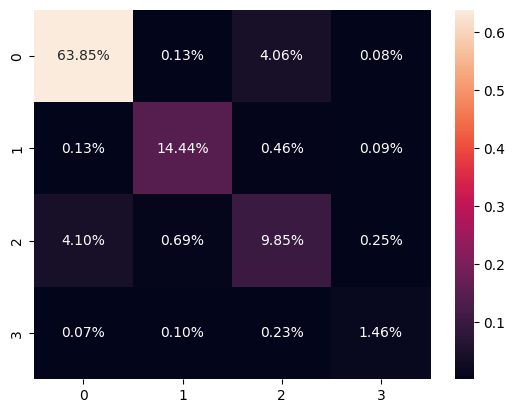

###################- End -###################
#############################################
######-Model => RandomForestClassifier 
Test Accuracy:  89.66%  
              Classification Report 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    128308
           1       0.92      0.96      0.94     28491
           2       0.70      0.61      0.65     28058
           3       0.88      0.75      0.81      3509

    accuracy                           0.90    188366
   macro avg       0.86      0.82      0.83    188366
weighted avg       0.89      0.90      0.89    188366

             Confusion Matrix 


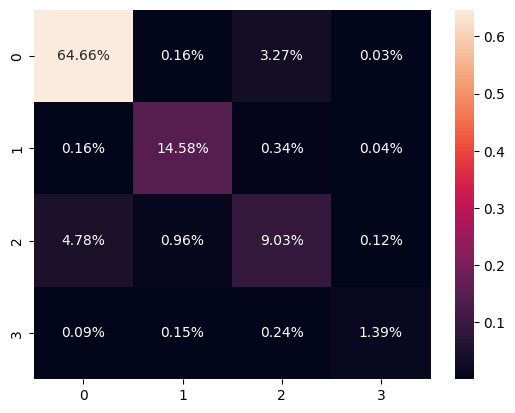

###################- End -###################
#############################################
######-Model => ExtraTreesClassifier 
Test Accuracy:  89.67%  
              Classification Report 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    128308
           1       0.93      0.97      0.95     28491
           2       0.70      0.61      0.65     28058
           3       0.88      0.76      0.81      3509

    accuracy                           0.90    188366
   macro avg       0.86      0.82      0.84    188366
weighted avg       0.89      0.90      0.89    188366

             Confusion Matrix 


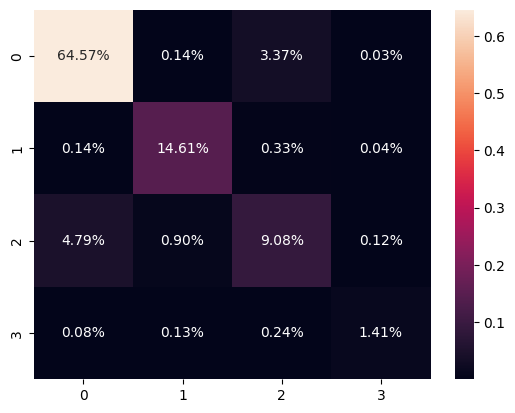

###################- End -###################


In [14]:
models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    ExtraTreesClassifier()
]

results = []

for model in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(type(model).__name__))
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_score = report['macro avg']['f1-score']
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    results.append({
        'Model': type(model).__name__,
        'Accuracy': accuracy,
        'F1-Score': f1_score,
        'Precision': precision,
        'Recall': recall
    })
    
    print('Test Accuracy:\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(accuracy * 100))
    print('\033[01m              Classification Report \033[0m')
    print(classification_report(y_test, y_pred))
    print('\033[01m             Confusion Matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, y_pred)
    plot_ = sns.heatmap(cf_matrix / np.sum(cf_matrix), annot=True, fmt='0.2%')
    plt.show()
    print('\033[31m###################- End -###################\033[0m')